# Data Loading and Preparation

In [133]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Make plots look nicer
sns.set_theme(style="whitegrid")
%matplotlib inline

In [134]:
# Helper functions
def category_distribution_by_label(category, subset):
    subset_count = subset[category].value_counts()
    subset_frac = subset_count/subset_count.sum()
    return pd.DataFrame({
        "subset_count": subset_count,
        "subset_frac": subset_frac
    }).sort_values(by="subset_count", ascending=False)

In [135]:
# Load raw UNSW-NB15 datasets and feature names
feature_metadata_path = Path("../data/raw/UNSW-NB15_features.csv")
data_paths = [
    Path("../data/raw/UNSW-NB15_1.csv"),
    Path("../data/raw/UNSW-NB15_2.csv"),
    Path("../data/raw/UNSW-NB15_3.csv"),
    Path("../data/raw/UNSW-NB15_4.csv")
]

# Read the features file
df_feature_metadata = pd.read_csv(feature_metadata_path, encoding="ISO-8859-1")
df_feature_metadata.head()

,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol


In [136]:
# Combine UNSW-NB15 CSVs into a single DataFrame and inspect structure
col_names = df_feature_metadata["Name"].tolist()
df_data_list = [pd.read_csv(data_path, names=col_names, low_memory=False) for data_path in data_paths]
df_data_combined = pd.concat(df_data_list, ignore_index=True) # Ensures unique indices across files

# Show first few rows
display(df_data_combined.head())

# Check shape
print("Dataset shape:", df_data_combined.shape)

# Info about data types and missing values
df_data_combined.info()

# Quick statistics for numeric columns
display(df_data_combined.describe())

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0,3,7,1,3,1,1,1,NaN,0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,NaN,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12,8,1,2,2,1,1,NaN,0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6,9,1,1,1,1,1,NaN,0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7,9,1,1,1,1,1,NaN,0


Dataset shape: (2540047, 49)
<class 'pandas.DataFrame'>
RangeIndex: 2540047 entries, 0 to 2540046
Data columns (total 49 columns):
 #   Column            Dtype  
---  ------            -----  
 0   srcip             str    
 1   sport             object 
 2   dstip             str    
 3   dsport            str    
 4   proto             str    
 5   state             str    
 6   dur               float64
 7   sbytes            int64  
 8   dbytes            int64  
 9   sttl              int64  
 10  dttl              int64  
 11  sloss             int64  
 12  dloss             int64  
 13  service           str    
 14  Sload             float64
 15  Dload             float64
 16  Spkts             int64  
 17  Dpkts             int64  
 18  swin              int64  
 19  dwin              int64  
 20  stcpb             int64  
 21  dtcpb             int64  
 22  smeansz           int64  
 23  dmeansz           int64  
 24  trans_depth       int64  
 25  res_bdy_len       int64  
 

,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,Sload,Dload,Spkts,...,ct_flw_http_mthd,is_ftp_login,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,Label
count,2.540047e+06,2.540047e+06,2.540047e+06,2.540047e+06,2.540047e+06,2.540047e+06,2.540047e+06,2.540047e+06,2.540047e+06,2.540047e+06,...,1.191902e+06,1.110168e+06,2.540047e+06,2.540047e+06,2.540047e+06,2.540047e+06,2.540047e+06,2.540047e+06,2.540047e+06,2.540047e+06
mean,6.587916e-01,4.339600e+03,3.642759e+04,6.278197e+01,3.076681e+01,5.163921e+00,1.632944e+01,3.695645e+07,2.450861e+06,3.328884e+01,...,2.345856e-01,3.969940e-02,9.206988e+00,8.988958e+00,6.439103e+00,6.900986e+00,4.642139e+00,3.592729e+00,6.845886e+00,1.264870e-01
std,1.392493e+01,5.640599e+04,1.610960e+05,7.462277e+01,4.285089e+01,2.251707e+01,5.659474e+01,1.186043e+08,4.224863e+06,7.628388e+01,...,7.940924e-01,1.996589e-01,1.083676e+01,1.082249e+01,8.162034e+00,8.205062e+00,8.477579e+00,6.174445e+00,1.125828e+01,3.323975e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,1.037000e-03,2.000000e+02,1.780000e+02,3.100000e+01,2.900000e+01,0.000000e+00,0.000000e+00,1.353963e+05,1.191594e+04,2.000000e+00,...,0.000000e+00,0.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
50%,1.586100e-02,1.470000e+03,1.820000e+03,3.100000e+01,2.900000e+01,3.000000e+00,4.000000e+00,5.893038e+05,5.893179e+05,1.200000e+01,...,0.000000e+00,0.000000e+00,5.000000e+00,5.000000e+00,3.000000e+00,4.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,0.000000e+00
75%,2.145545e-01,3.182000e+03,1.489400e+04,3.100000e+01,2.900000e+01,7.000000e+00,1.400000e+01,2.039923e+06,2.925974e+06,4.400000e+01,...,0.000000e+00,0.000000e+00,1.000000e+01,1.000000e+01,6.000000e+00,7.000000e+00,2.000000e+00,1.000000e+00,5.000000e+00,0.000000e+00
max,8.786638e+03,1.435577e+07,1.465753e+07,2.550000e+02,2.540000e+02,5.319000e+03,5.507000e+03,5.988000e+09,1.287619e+08,1.064600e+04,...,3.600000e+01,4.000000e+00,6.700000e+01,6.700000e+01,6.700000e+01,6.700000e+01,6.700000e+01,6.000000e+01,6.700000e+01,1.000000e+00


In [137]:
# Prepare dataset for EDA and visualisation
df_eda = df_data_combined.sample(frac=0.1, random_state=42) # Use only 10% of dataset for speed and interpretability

# Show first few rows
display(df_eda.head())

# Check shape
print("Sample shape:", df_eda.shape)

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
53230,59.166.0.5,6807,149.171.126.6,21,tcp,FIN,0.883703,2934,3742,31,...,1,1,1,6,3,1,1,3,NaN,0
1823779,59.166.0.8,3083,149.171.126.8,1106,tcp,FIN,0.331832,5486,94690,31,...,,5,1,3,3,1,1,1,NaN,0
2479738,149.171.126.10,1043,175.45.176.0,53,udp,INT,0.000007,264,0,60,...,,31,31,31,31,31,15,31,NaN,0
923745,59.166.0.5,13382,149.171.126.2,53,udp,CON,0.001122,130,162,31,...,0,1,3,2,2,1,1,1,NaN,0
1700724,59.166.0.7,34971,149.171.126.1,80,tcp,FIN,1.122783,1580,10168,31,...,,1,2,9,4,1,1,1,NaN,0


Sample shape: (254005, 49)


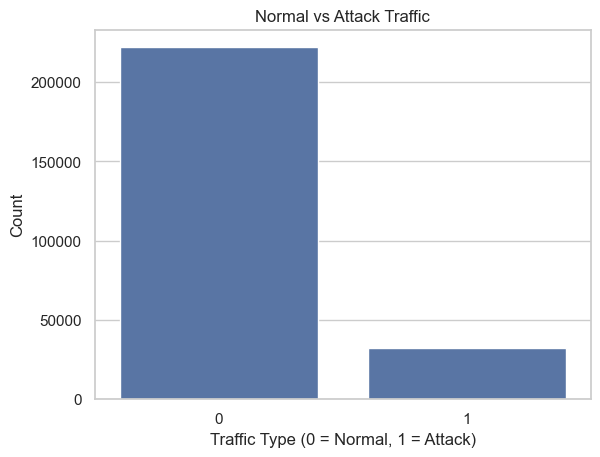

In [138]:
# Visualise traffic class balance
sns.countplot(x="Label", data=df_eda)
plt.xlabel("Traffic Type (0 = Normal, 1 = Attack)")
plt.ylabel("Count")
plt.title("Normal vs Attack Traffic")
plt.show()

# Byte-Based Features

Visualising byte distributions to understand volume patterns.

## Source and Destination Byte Distributions

### Source Bytes

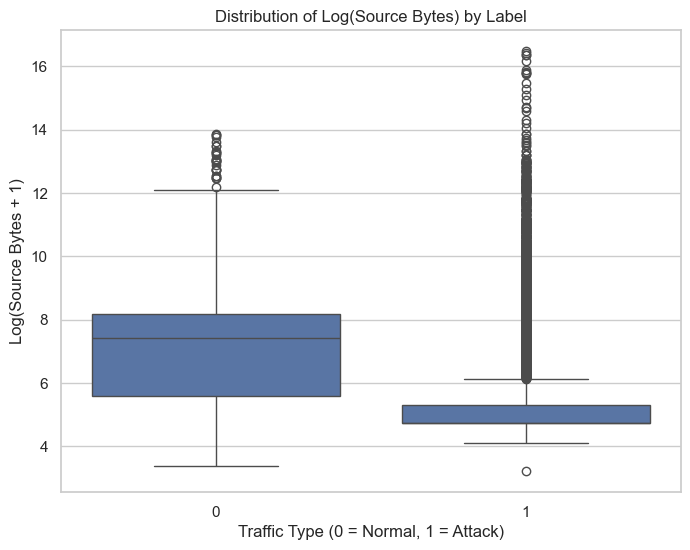

In [139]:
# Compare distribution of source bytes across traffic types (log-scaled)
plt.figure(figsize=(8, 6))
sns.boxplot(x="Label", y=np.log1p(df_eda["sbytes"]), data=df_eda) # Apply scaling inline for visualisation only
plt.xlabel("Traffic Type (0 = Normal, 1 = Attack)")
plt.ylabel("Log(Source Bytes + 1)")
plt.title("Distribution of Log(Source Bytes) by Label")
plt.show()

**Observations:**
- **Normal flows (Label=0)**
    - Wider spread in source bytes, reflecting the greater variety of normal network activity (e.g., quick checks vs file transfers).
- **Attack flows (Label=1)**
    - Much more concentrated (far lower spread), but with many extreme values/outliers that stretch the tail.
    - Likely due to automated attacks sending consistently low bytes, with occasional high-byte floods, exfiltrations or DoS attempts.
    - Extreme values exceeding normal outliers could be informative for distinguishing anomalies.

### Destination Bytes

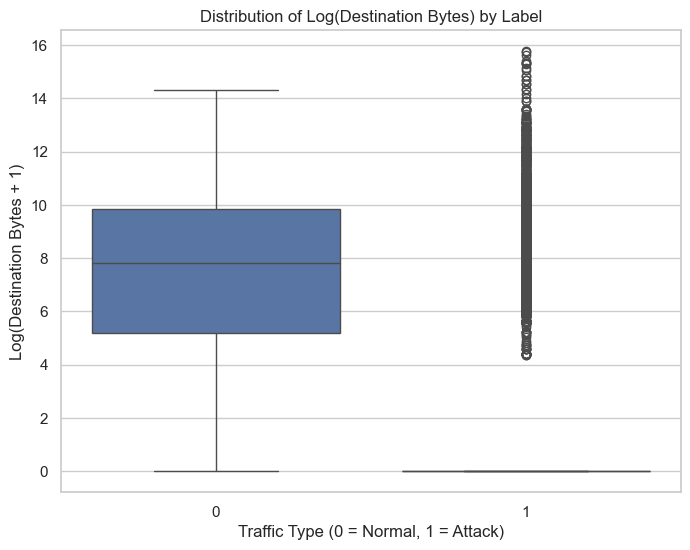

In [140]:
# Compare distribution of destination bytes across traffic types (log-scaled)
plt.figure(figsize=(8, 6))
sns.boxplot(x="Label", y=np.log1p(df_eda["dbytes"]), data=df_eda)
plt.xlabel("Traffic Type (0 = Normal, 1 = Attack)")
plt.ylabel("Log(Destination Bytes + 1)")
plt.title("Distribution of Log(Destination Bytes) by Label")
plt.show()

**Observations:**
- **Normal flows (Label=0)**
    - Wider spread in destination bytes, reflecting the greater variety of normal network activity (e.g., quick checks vs file transfers).
- **Attack flows (Label=1)**
    - Squashed to zero, but with many extreme values/outliers that stretch the tail.
    - Could result from attacks that are immediately blocked or overwhelm the destination, yielding zero response.
    - Non-zero outliers might represent partial server responses, targeted probes that elicit some replies or larger/verbose error messages.
    - Zero destination bytes can be a strong indicator of malicious activity.

### Scatter Plot

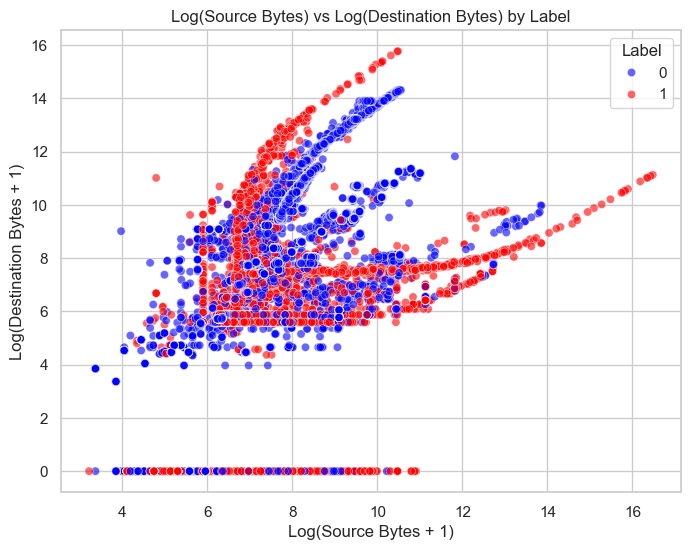

In [141]:
# Scatter scaled relationship between source and destination bytes
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=np.log1p(df_eda["sbytes"]),
    y=np.log1p(df_eda["dbytes"]),
    data=df_eda,
    hue="Label",
    alpha=0.6,
    palette={0: "blue", 1: "red"}
)
plt.xlabel("Log(Source Bytes + 1)")
plt.ylabel("Log(Destination Bytes + 1)")
plt.title("Log(Source Bytes) vs Log(Destination Bytes) by Label")
plt.show()

**Observations:**
- **Normal flows (Label=0)**
    - Tend to lie along a central diagonal, signifying roughly proportional source and destination bytes.
- **Attack flows (Label=1)**
    - Deviate from the diagonal, showing an imbalance between source and destination bytes.
    - This byte imbalance could be leveraged to help distinguish malicious flows.
- Note that quite a number of normal flows (potentially one-way checks, connection resets, etc.) also have zero destination bytes.

## Derived Byte Distributions

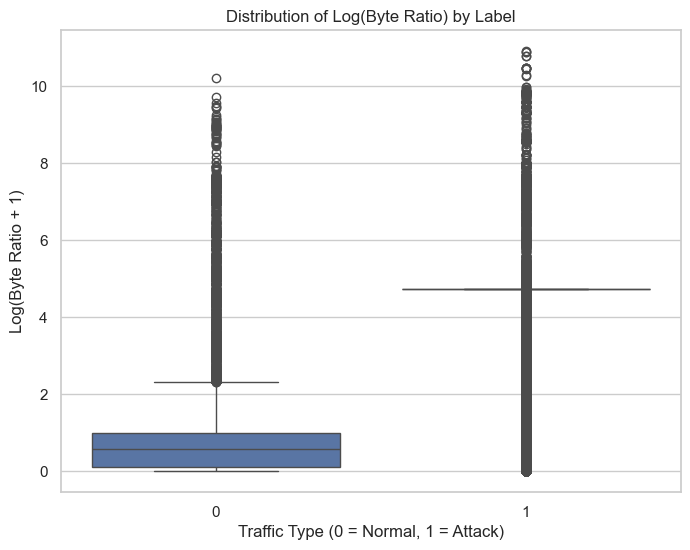

In [142]:
# Highlight flows with directionally imbalanced volumes
log_byte_ratio = np.log1p(df_eda["sbytes"]/(df_eda["dbytes"] + 1))
plt.figure(figsize=(8, 6))
sns.boxplot(x="Label", y=log_byte_ratio, data=df_eda)
plt.xlabel("Traffic Type (0 = Normal, 1 = Attack)")
plt.ylabel("Log(Byte Ratio + 1)")
plt.title("Distribution of Log(Byte Ratio) by Label")
plt.show()

**Observations:**
- The attack median is well separated from the normal median, suggesting some discriminatory power.
- However, the sheer volume of extreme normal outliers may dilute this signal, rendering higher ratios more typical than expected.
- Attack outliers stretch toward zero, overlapping with the normal box and further reducing clarity.

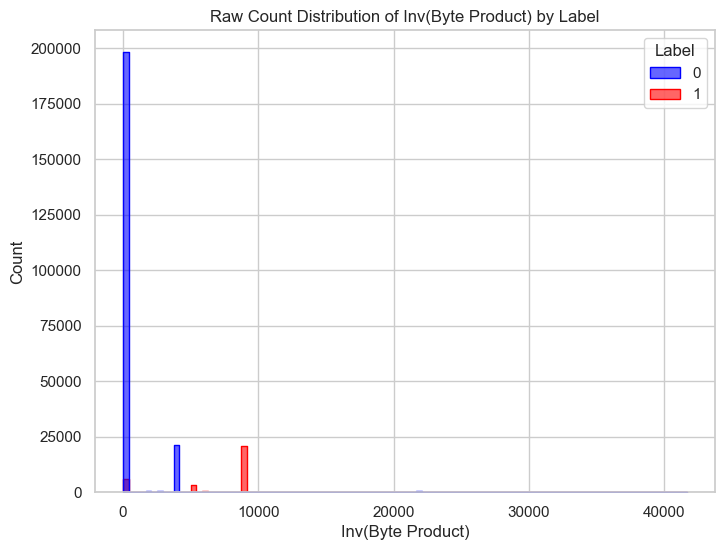

In [ ]:
# Plot raw count distribution of inverse byte product by label
plt.figure(figsize=(8, 6))
sns.histplot(
    data=df_eda,
    x=inv_byte_prod,
    hue="Label",
    bins=100,
    element="step",
    alpha=0.6,
    palette={0: "blue", 1: "red"}
)
plt.xlabel("Inv(Byte Product)")
plt.ylabel("Count")
plt.title("Raw Count Distribution of Inv(Byte Product) by Label")
plt.show()

**Observations:**
- Attack flows tend to cluster around higher inverse byte product values compared to normal flows, indicating extremely small byte volumes.
- Normal flows have a wider spread, with many low- and mid-range ratios, reflecting diverse legitimate activity.
- Some overlap between classes at lower values, but attack cluster remains distinct.

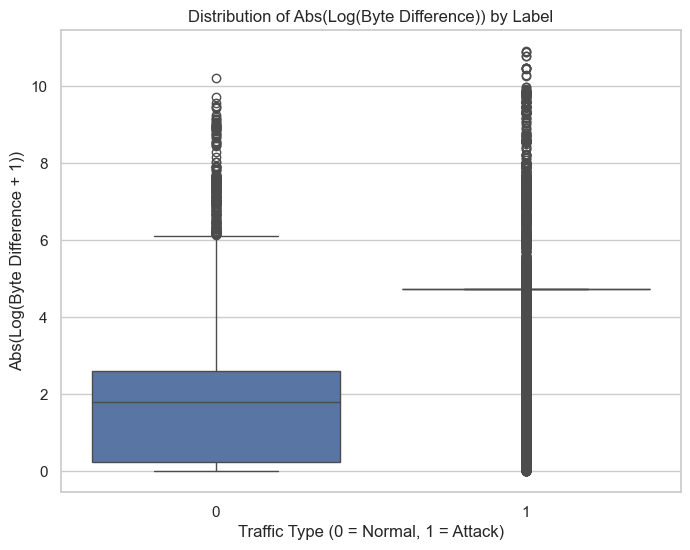

In [144]:
# Highlight unusual combinations and directional imbalance
abs_log_byte_diff = abs(np.log1p(df_eda["sbytes"]) - np.log1p(df_eda["dbytes"]))
plt.figure(figsize=(8, 6))
sns.boxplot(x="Label", y=abs_log_byte_diff, data=df_eda)
plt.xlabel("Traffic Type (0 = Normal, 1 = Attack)")
plt.ylabel("Abs(Log(Byte Difference + 1))")
plt.title("Distribution of Abs(Log(Byte Difference)) by Label")
plt.show()

**Observations:**
- Attack flows show a higher, well separated median reflecting greater imbalance.
- Extreme normal outliers reduce clarity, making larger, legitimate differences more typical than expected.
- Some outlier attacks are balanced, stretching towards zero and overlapping with the normal tail.

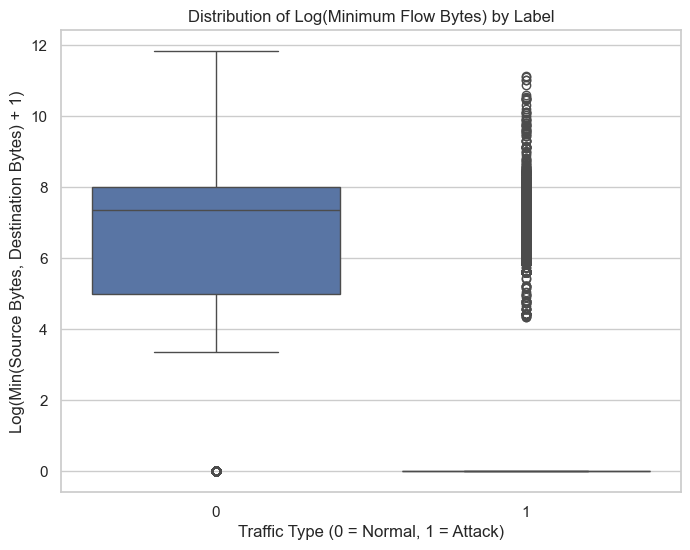

In [145]:
# Downweight bidirectional network flows
log_min_flow_bytes = np.log1p(np.minimum(df_eda["sbytes"], df_eda["dbytes"]))
plt.figure(figsize=(8, 6))
sns.boxplot(x="Label", y=log_min_flow_bytes, data=df_eda)
plt.xlabel("Traffic Type (0 = Normal, 1 = Attack)")
plt.ylabel("Log(Min(Source Bytes, Destination Bytes) + 1)")
plt.title("Distribution of Log(Minimum Flow Bytes) by Label")
plt.show()

**Observations:**
- Highlights extremely low-volume, highly imbalanced attack flows.
- Some outliers still exist that are both balanced and high-volume, reducing perfect separation.

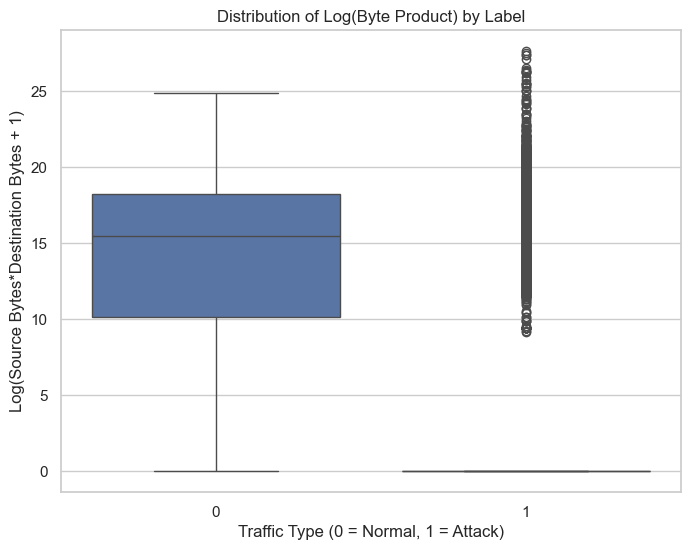

In [146]:
# Explore combined flow volume
log_byte_prod = np.log1p(df_eda["sbytes"]*df_eda["dbytes"])
plt.figure(figsize=(8, 6))
sns.boxplot(x="Label", y=log_byte_prod, data=df_eda)
plt.xlabel("Traffic Type (0 = Normal, 1 = Attack)")
plt.ylabel("Log(Source Bytes*Destination Bytes + 1)")
plt.title("Distribution of Log(Byte Product) by Label")
plt.show()

**Observations:**
- Strong separation between attack and normal boxes.
    - Attack box is squashed toward zero, reflecting low-volume nature of most attack flows.
- Large number of extreme attack outliers overlap with the normal distribution, which may dilute discriminatory power of this feature.

# Time-Based Features

Visualising duration distributions to understand temporal patterns.

## Flow Duration Distributions

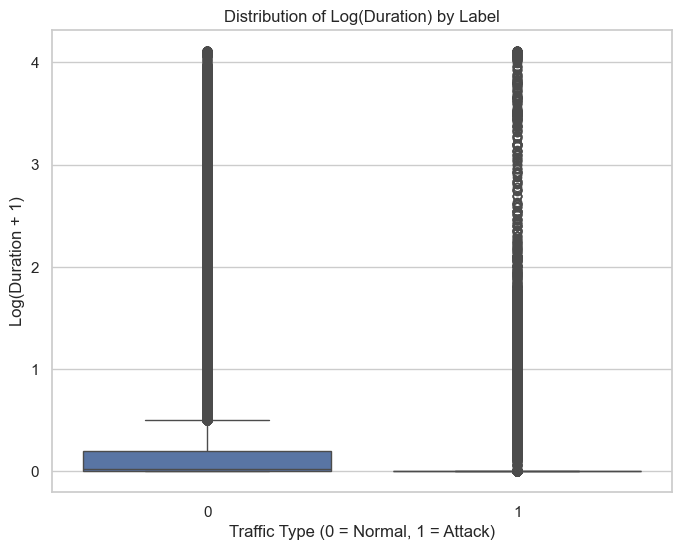

In [147]:
# Compare distribution of duration across traffic types (log-scaled)
plt.figure(figsize=(8, 6))
sns.boxplot(x="Label", y=np.log1p(df_eda["dur"]), data=df_eda)
plt.xlabel("Traffic Type (0 = Normal, 1 = Attack)")
plt.ylabel("Log(Duration + 1)")
plt.title("Distribution of Log(Duration) by Label")
plt.show()

**Observations:**
- **Normal flows (Label=0)**
    - Much larger spread than attack flows, reflecting diverse durations of legitimate activity (e.g., browsing, streaming)
    - Heavy right tail, likely due to abnormally long downloads or sessions.
    - Near-zero durations might occur as a result of quick checks or failed connections.
- **Attack flows (Label=1)**
    - Box is squashed to zero, indicating most attacks are short-lived.
    - Right-skewed tail represents persistent attacks, such as brute-force attempts or prolonged scans.

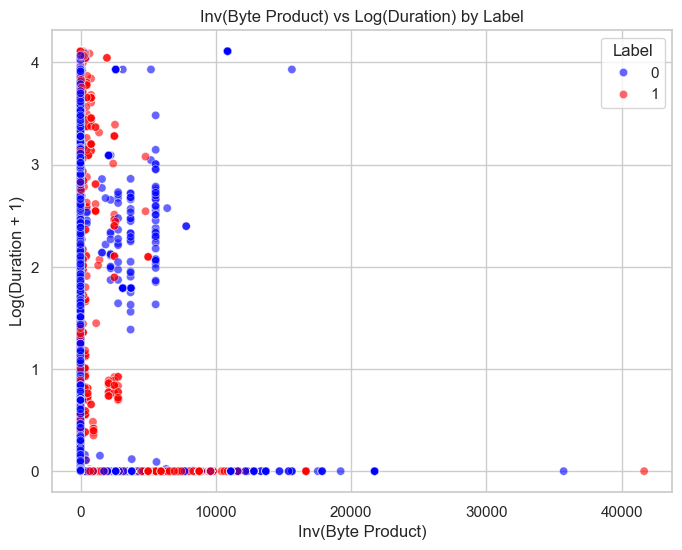

In [149]:
# Scatter relationship between inverse byte product and duration
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_eda,
    x=inv_byte_prod,
    y=np.log1p(df_eda["dur"]),
    hue="Label",
    alpha=0.6,
    palette={0: "blue", 1: "red"}
)
plt.xlabel("Inv(Byte Product)")
plt.ylabel("Log(Duration + 1)")
plt.title("Inv(Byte Product) vs Log(Duration) by Label")
plt.show()

## Endpoint Load Distributions

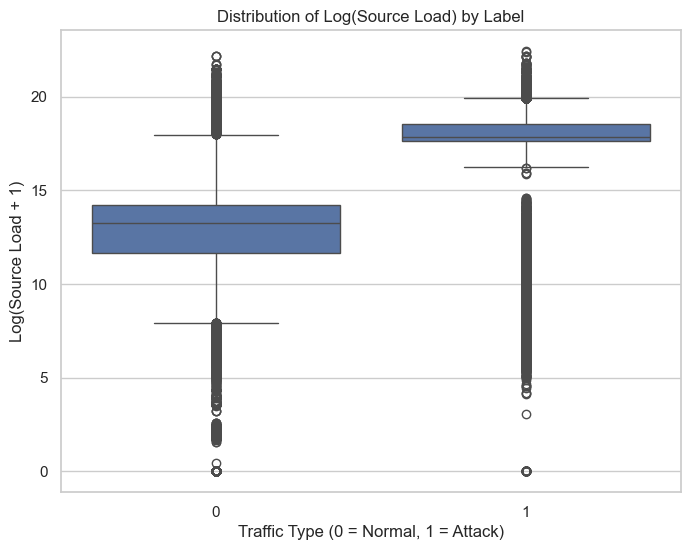

In [150]:
# Compare distribution of source load across traffic types (log-scaled)
plt.figure(figsize=(8, 6))
sns.boxplot(x="Label", y=np.log1p(df_eda["Sload"]), data=df_eda)
plt.xlabel("Traffic Type (0 = Normal, 1 = Attack)")
plt.ylabel("Log(Source Load + 1)")
plt.title("Distribution of Log(Source Load) by Label")
plt.show()

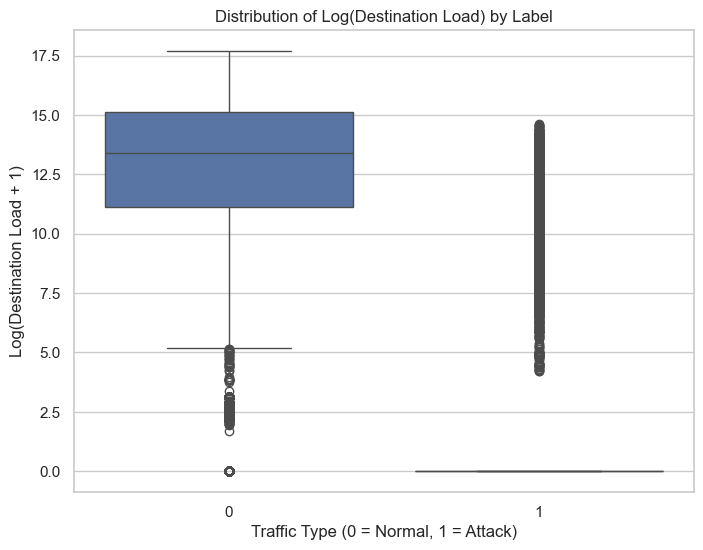

In [151]:
# Compare distribution of destination load across traffic types (log-scaled)
plt.figure(figsize=(8, 6))
sns.boxplot(x="Label", y=np.log1p(df_eda["Dload"]), data=df_eda)
plt.xlabel("Traffic Type (0 = Normal, 1 = Attack)")
plt.ylabel("Log(Destination Load + 1)")
plt.title("Distribution of Log(Destination Load) by Label")
plt.show()

**Observations:**
- **Source load**
    - Attack values are inflated due to the short durations of attack flows.
    - Distributions overlap heavily; might not yield much more signal beyond the raw duration feature.
- **Destination load**
    - Attack values are deflated due to low numbers of destination bytes.
    - Well separated distributions could offer another dimension to exploit low-volume flows.

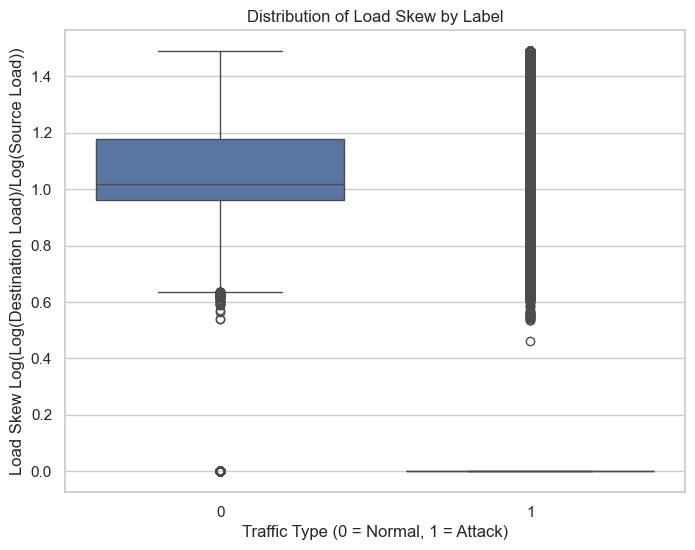

In [152]:
# Highlight flows with directionally imbalanced loads
load_skew = np.log1p(df_eda["Dload"])/(np.log1p(df_eda["Sload"]) + 1e-6)
load_skew = load_skew.clip(upper=load_skew.quantile(0.999))
plt.figure(figsize=(8, 6))
sns.boxplot(x="Label", y=load_skew, data=df_eda)
plt.xlabel("Traffic Type (0 = Normal, 1 = Attack)")
plt.ylabel("Load Skew Log(Log(Destination Load)/Log(Source Load))")
plt.title("Distribution of Load Skew by Label")
plt.show()

**Observations:**
- Captures low-volume or one-way attacks where the destination responds very little relative to source activity.
- Cleanly isolates malicious flows (attack box shows minimal overlap with normal outliers).

## Endpoint Jitter Distributions

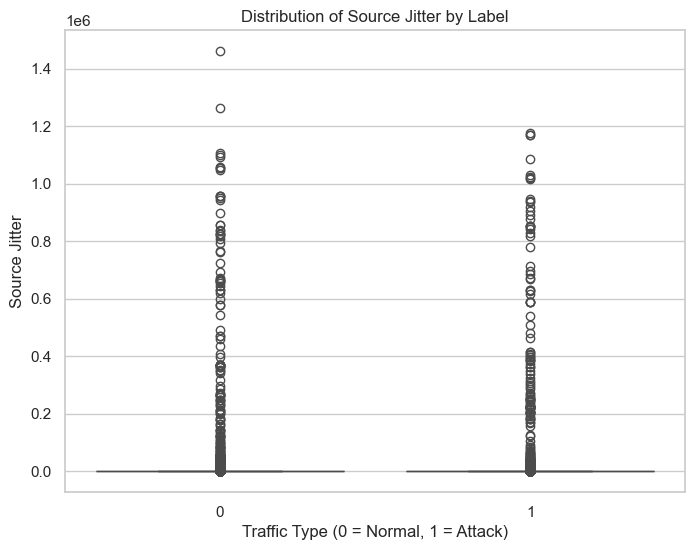

In [153]:
# Compare distribution of source jitter across traffic types
plt.figure(figsize=(8, 6))
sns.boxplot(x="Label", y="Sjit", data=df_eda)
plt.xlabel("Traffic Type (0 = Normal, 1 = Attack)")
plt.ylabel("Source Jitter")
plt.title("Distribution of Source Jitter by Label")
plt.show()

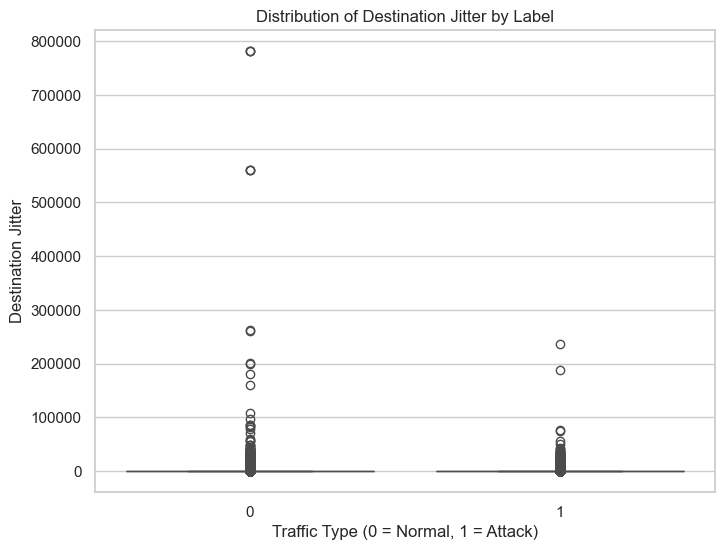

In [154]:
# Compare distribution of destination jitter across traffic types
plt.figure(figsize=(8, 6))
sns.boxplot(x="Label", y="Djit", data=df_eda)
plt.xlabel("Traffic Type (0 = Normal, 1 = Attack)")
plt.ylabel("Destination Jitter")
plt.title("Distribution of Destination Jitter by Label")
plt.show()

**Observations:**
- Both source and destination jitter features exhibit significant overlap between attack and normal distributions.
- Unlikely to offer meaningful discriminatory power for isolation-based detection.

## Recurrence Count Distributions

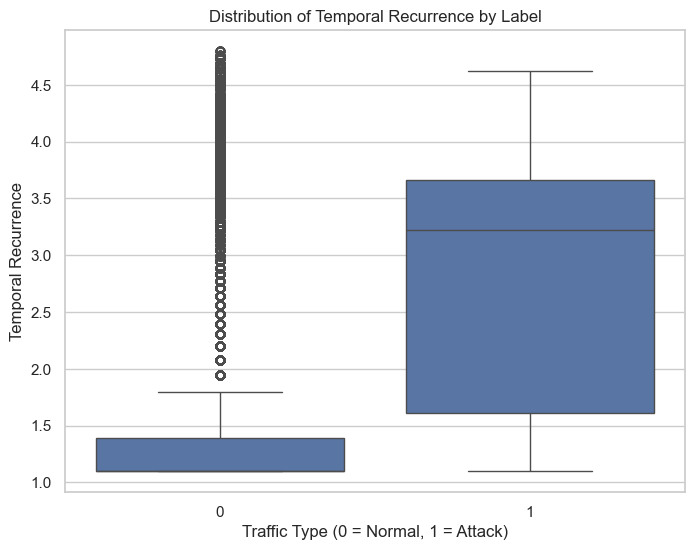

In [172]:
# Experiment with temporal repetition
temporal_recurrence = np.log1p(df_eda["ct_src_dport_ltm"] + df_eda["ct_dst_sport_ltm"])
plt.figure(figsize=(8, 6))
sns.boxplot(x="Label", y=temporal_recurrence, data=df_eda)
plt.xlabel("Traffic Type (0 = Normal, 1 = Attack)")
plt.ylabel("Temporal Recurrence")
plt.title("Distribution of Temporal Recurrence by Label")
plt.show()

**Observations:**
- Attacks trend higher than normal flows on average, likely reflecting automated sources repeatedly hitting the same destinations.
- While the boxes show nice separation, the long tail of normal flows stretches far enough to encompass the entire attack distribution.
- By sheer volume this overlap might prevent isolation via simple thresholding, diluting the signal.

# Packet-Level Features

Visualising size distributions to understand packet patterns.

## Source and Destination Mean Packet Size Distributions

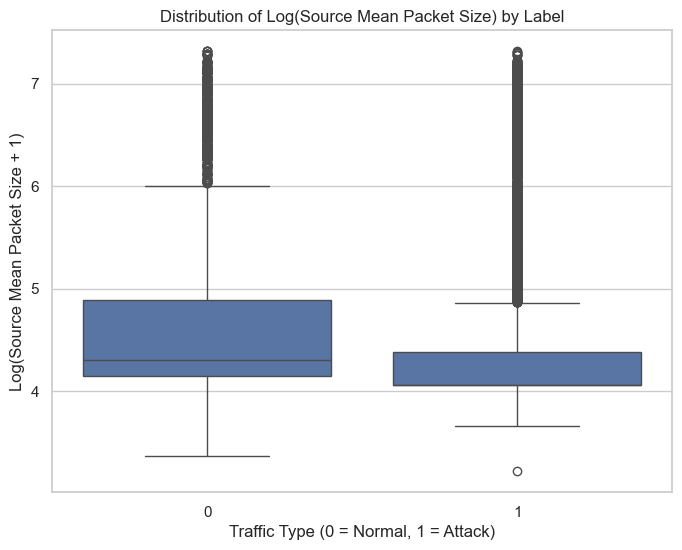

In [156]:
# Compare distribution of source mean packet size across traffic types (log-scaled)
plt.figure(figsize=(8, 6))
sns.boxplot(x="Label", y=np.log1p(df_eda["smeansz"]), data=df_eda)
plt.xlabel("Traffic Type (0 = Normal, 1 = Attack)")
plt.ylabel("Log(Source Mean Packet Size + 1)")
plt.title("Distribution of Log(Source Mean Packet Size) by Label")
plt.show()

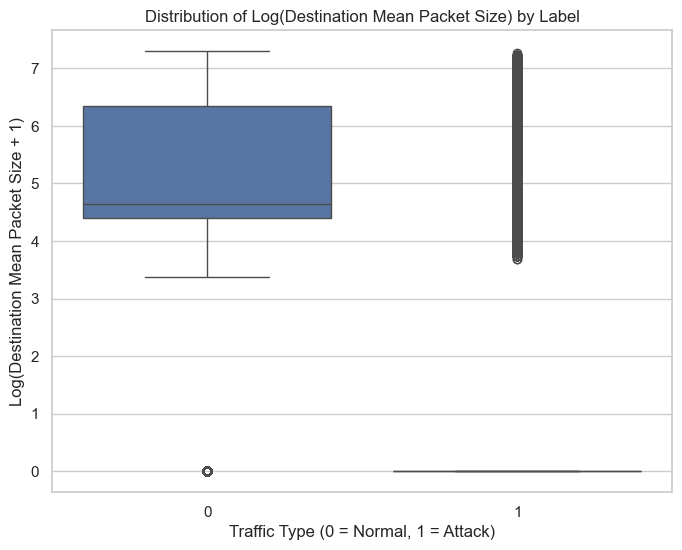

In [157]:
# Compare distribution of destination mean packet size across traffic types (log-scaled)
plt.figure(figsize=(8, 6))
sns.boxplot(x="Label", y=np.log1p(df_eda["dmeansz"]), data=df_eda)
plt.xlabel("Traffic Type (0 = Normal, 1 = Attack)")
plt.ylabel("Log(Destination Mean Packet Size + 1)")
plt.title("Distribution of Log(Destination Mean Packet Size) by Label")
plt.show()

**Observations:**
- Mean packet sizes mirror raw byte distributions, given they are derived via dividing by packet count.
- It's likely that most flows (particularly normal ones) are confined to certain characteristic size ranges that are dictated by the underlying network technology.
- Coming back after Stage 2 correlation analysis, these features are likely to be highly correlated even during Stage 1.
- Effect is only pronounced post-filtering since attack flows are more uniform in nature.

## Derived Mean Packet Size Distributions

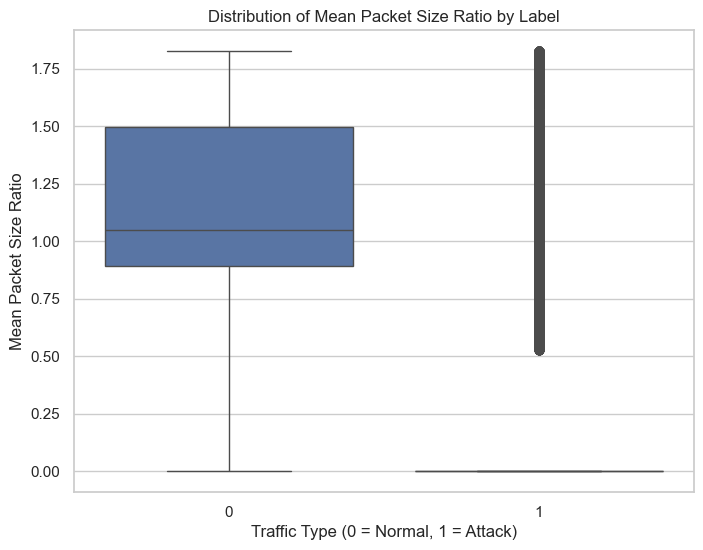

In [158]:
# Highlight flows with directionally imbalanced mean packet sizes
mean_pkt_sz_ratio = np.log1p(df_eda["dmeansz"])/(np.log1p(df_eda["smeansz"]) + 1e-6)
mean_pkt_sz_ratio = mean_pkt_sz_ratio.clip(upper=mean_pkt_sz_ratio.quantile(0.999))
plt.figure(figsize=(8, 6))
sns.boxplot(x="Label", y=mean_pkt_sz_ratio, data=df_eda)
plt.xlabel("Traffic Type (0 = Normal, 1 = Attack)")
plt.ylabel("Mean Packet Size Ratio")
plt.title("Distribution of Mean Packet Size Ratio by Label")
plt.show()

# TTL Features

Visualising time-to-live distributions to understand hop patterns.

## Source and Destination TTL Distributions

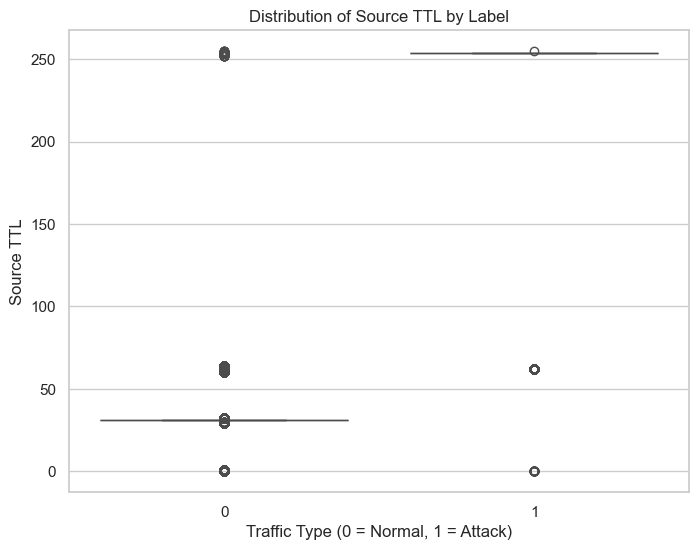

In [159]:
# Compare distribution of source ttl across traffic types
plt.figure(figsize=(8, 6))
sns.boxplot(x="Label", y="sttl", data=df_eda)
plt.xlabel("Traffic Type (0 = Normal, 1 = Attack)")
plt.ylabel("Source TTL")
plt.title("Distribution of Source TTL by Label")
plt.show()

**Observations:**
- **Normal flows (Label=0)**
    - TTL values are tightly clustered around ~30.
    - Likely reflects that most legitimate traffic originates from similar, closeby network regions (people in the area).
- **Attack flows (Label=1)**
    - TTL values are tightly clustered around ~250.
    - Could indicate malicious traffic from similar spoofed/proxy IPs or distant but common attack sources.

Feature shows extreme separation between attack and normal flows. The only potential dilution is the presence of outliers in each group that lie around the other group's median.

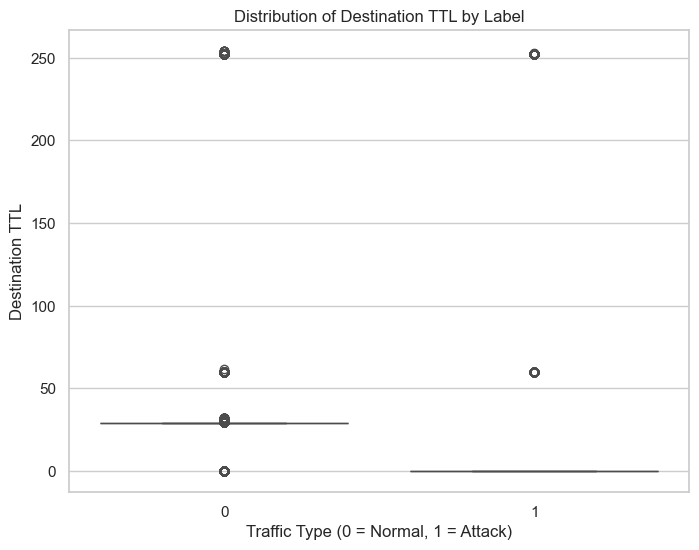

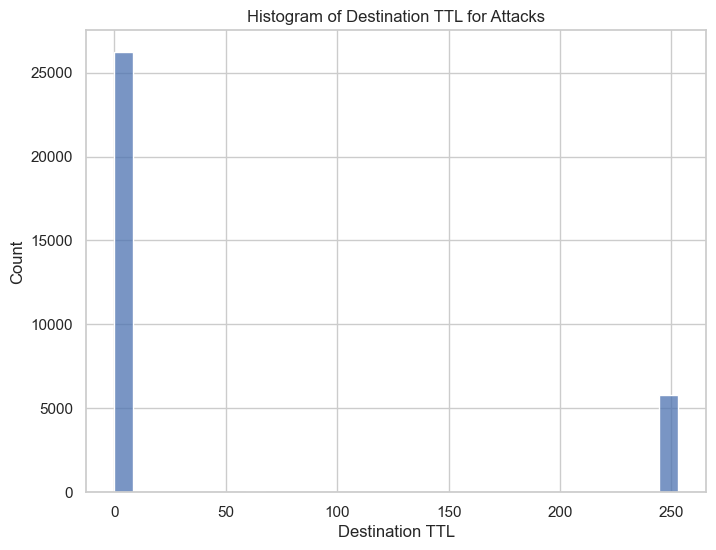

In [160]:
# Compare distribution of destination TTL across traffic types
plt.figure(figsize=(8, 6))
sns.boxplot(x="Label", y="dttl", data=df_eda)
plt.xlabel("Traffic Type (0 = Normal, 1 = Attack)")
plt.ylabel("Destination TTL")
plt.title("Distribution of Destination TTL by Label")
plt.show()

# Visualise bimodality for attacks
plt.figure(figsize=(8, 6))
sns.histplot(df_eda[df_eda["Label"]==1]["dttl"], bins=30, kde=False)
plt.title("Histogram of Destination TTL for Attacks")
plt.xlabel("Destination TTL")
plt.ylabel("Count")
plt.show()

**Observations:**
- Similarly strong separation as STTL is apparent, with each group tightly clustered around its median.
- DTTL values of zero are likely due to logging defaults or missing/dropped destination packets, highlighting flows with no response.

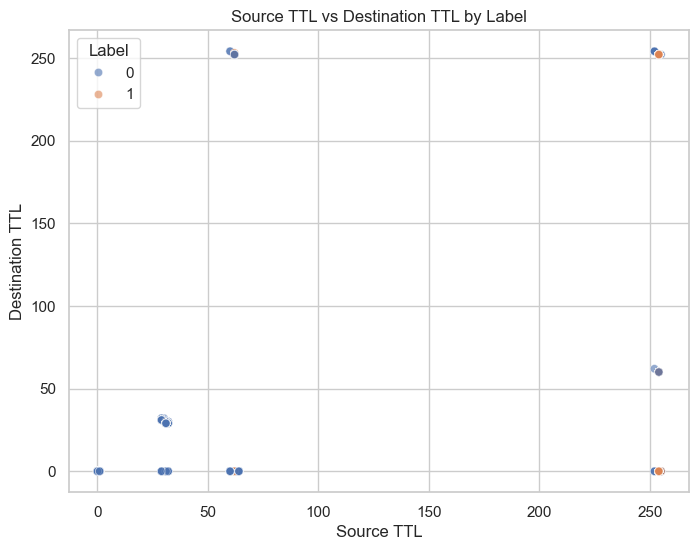

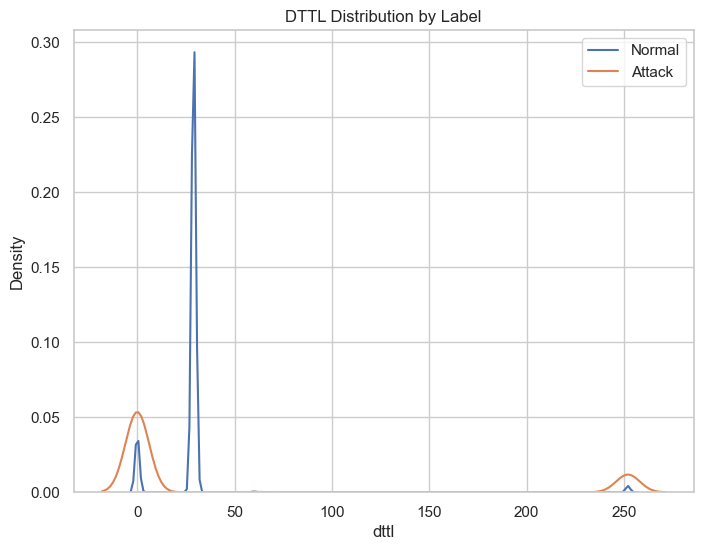

In [161]:
# Scatter relationship between source TTL and destination TTL
plt.figure(figsize=(8, 6))
sns.scatterplot(x="sttl", y="dttl", hue="Label", data=df_eda, alpha=0.6)
plt.xlabel("Source TTL")
plt.ylabel("Destination TTL")
plt.title("Source TTL vs Destination TTL by Label")
plt.show()

# Comparative histograms
plt.figure(figsize=(8, 6))
sns.kdeplot(df_eda[df_eda['Label']==0]['dttl'], label='Normal', bw_adjust=0.5)
sns.kdeplot(df_eda[df_eda['Label']==1]['dttl'], label='Attack', bw_adjust=0.5)
plt.title("DTTL Distribution by Label")
plt.legend()
plt.show()

**Observations:**
- Despite strong separation of STTL and DTTL individually, attack and normal flows cannot be perfectly separated along the combination of these two axes.
- Points form distinct clusters but outliers approaching the other group's median create overlap and prevent clean isolation.

## Derived TTL Distributions

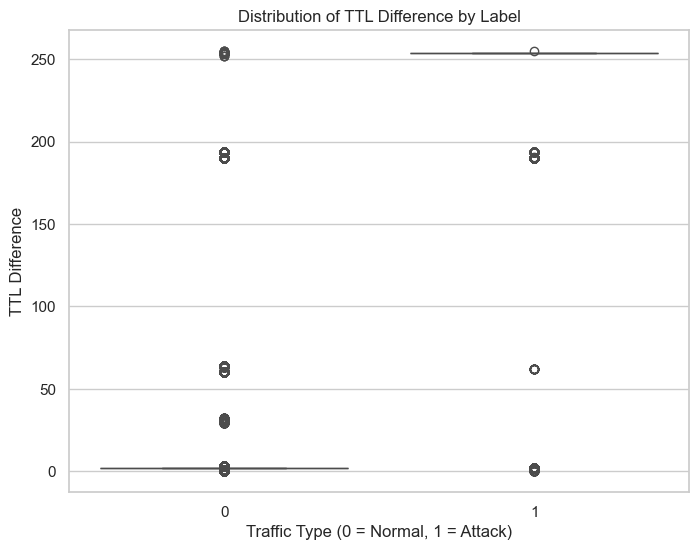

In [162]:
# Highlight unusual TTL combinations
ttl_diff = abs(df_eda["sttl"] - df_eda["dttl"])
plt.figure(figsize=(8, 6))
sns.boxplot(x="Label", y=ttl_diff, data=df_eda)
plt.xlabel("Traffic Type (0 = Normal, 1 = Attack)")
plt.ylabel("TTL Difference")
plt.title("Distribution of TTL Difference by Label")
plt.show()

## Checking Feature Correlation with Label

In [163]:
# Data leakage
pd.crosstab(
    df_eda["ct_state_ttl"] > 0,
    df_eda["Label"],
    normalize="columns"
)

Label,0,1
ct_state_ttl,,
False,0.981312,0.003147
True,0.018688,0.996853


# Categorical Features

## Initial Exploration of Distributions

### Identify and Inspect Categorical Features

In [164]:
categorical_features = df_eda.select_dtypes(include=["object", "category", "str"]).columns.tolist()
low_card_numeric = [col for col in df_eda.select_dtypes(include=[int, float]).columns if df_eda[col].nunique() <= 10]
categorical_features += low_card_numeric
print(categorical_features)

for col in ["sport", "dsport", "state", "service", "proto"]:
    print(f"\nValue counts for {col}:")
    display(df_eda[col].value_counts().head(10)) # Top 10 categories

['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'service', 'ct_ftp_cmd', 'attack_cat', 'dttl', 'swin', 'dwin', 'trans_depth', 'is_sm_ips_ports', 'ct_state_ttl', 'is_ftp_login', 'Label']

Value counts for sport:


sport
1043     21563
47439    19386
0         4461
0          998
47439      654
1043       586
138        363
5060        54
2048        34
137         30
Name: count, dtype: int64


Value counts for dsport:


dsport
53      79545
80      22753
6881    12507
5190    11998
111      9276
25       8809
0        5465
22       5195
143      5019
21       4989
Name: count, dtype: int64


Value counts for state:


state
FIN    148052
CON     55951
INT     48920
REQ       950
RST        55
ECO        32
CLO        19
URH        13
ACC         4
PAR         3
Name: count, dtype: int64


Value counts for service:


service
-           125255
dns          77787
http         20597
ftp-data     12463
smtp          8097
ftp           4826
ssh           4815
pop3           121
dhcp            16
ssl             13
Name: count, dtype: int64


Value counts for proto:


proto
tcp      149801
udp       98693
unas       1622
arp        1028
ospf        752
sctp        163
icmp         54
any          40
pim          33
swipe        30
Name: count, dtype: int64

**Observations:**
- Several categorical features exhibit long-tailed distributions, reflecting sparse services or ephemeral port usage.
- However, the majority of flows are concentrated within a relatively small set of high-frequency categories.
- Top 10 most common values account for most traffic volume, suggesting rare categories contribute marginally to overall structure.

### Examine Key Features

#### Define Attack and Normal Subsets

In [165]:
attack_subset = df_eda[df_eda["Label"] == 1]
normal_subset = df_eda[df_eda["Label"] == 0]

#### Compare Distributions by Label

In [170]:
for col in ["state", "service", "proto"]:
    # Attack distribution
    print(f"\nTop {col} values for attacks:")
    display(category_distribution_by_label(col, attack_subset).head(5))

    # Normal distribution
    print(f"\nTop {col} values for normals:")
    display(category_distribution_by_label(col, normal_subset).head(5))


Top state values for attacks:


,subset_count,subset_frac
state,,
INT,26110,0.813548
FIN,5731,0.178569
CON,151,0.004705
REQ,102,0.003178



Top state values for normals:


,subset_count,subset_frac
state,,
FIN,142321,0.641343
CON,55800,0.251452
INT,22810,0.102789
REQ,848,0.003821
RST,55,0.000248



Top service values for attacks:


...

,subset_count,subset_frac
service,,
-,117210,0.528185
dns,56731,0.255648
http,18729,0.084399
ftp-data,12269,0.055288
smtp,7627,0.034370



Top proto values for attacks:


,subset_count,subset_frac
proto,,
udp,22366,0.696890
tcp,5764,0.179597
unas,1622,0.050539
ospf,291,0.009067
sctp,163,0.005079



Top proto values for normals:


,subset_count,subset_frac
proto,,
tcp,144037,0.649076
udp,76327,0.343953
arp,1028,0.004632
ospf,461,0.002077
icmp,54,0.000243


**Observations:**
- The top categories for attack and normal flows show significant overlap.
- The majority of flows in each class are concentrated in the same high-frequency categories.
- Will likely cause too much blending if used as discriminative input.

## Thorough Examination of Candidates

is_sm_ips_ports
0    32094
Name: count, dtype: int64 is_sm_ips_ports
0    221493
1       418
Name: count, dtype: int64


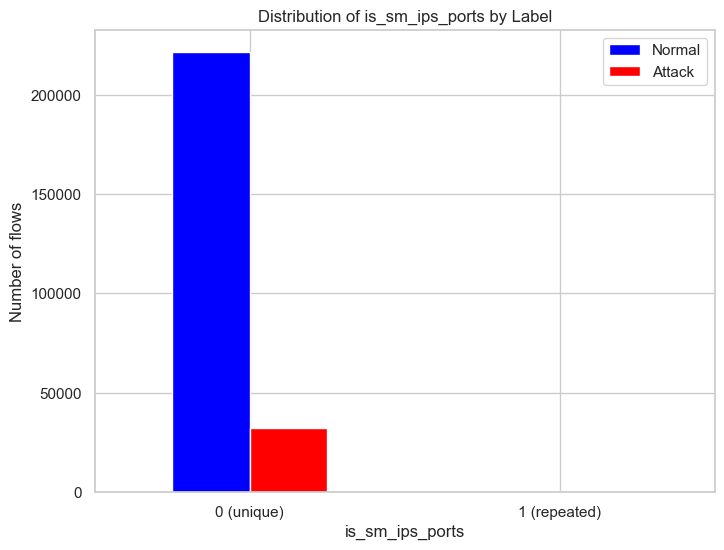

In [167]:
# Compare distribution of "is_sm_ips_ports" across traffic types
attack_counts = attack_subset["is_sm_ips_ports"].value_counts().sort_index()
normal_counts = normal_subset["is_sm_ips_ports"].value_counts().sort_index()
print(attack_counts, normal_counts)

df_counts = pd.DataFrame({
    "Normal": normal_counts,
    "Attack": attack_counts
}).fillna(0)

# Plot as bar chart
df_counts.plot(kind="bar", figsize=(8, 6), color={"Normal": "blue", "Attack": "red"})
plt.title("Distribution of is_sm_ips_ports by Label")
plt.xlabel("is_sm_ips_ports")
plt.ylabel("Number of flows")
plt.xticks([0, 1], ["0 (unique)", "1 (repeated)"], rotation=0)
plt.show()

**Observations:**
- Despite expecting attacks to repeat combinations, not a single attack repeats/shares the same combination as another flow.
- Might be due to attacks being single-shot or recorded independently despite targeting the same destinations.
- In this dataset, the feature will likely be uninformative for an isolation forest model but generally it should encode meaningful information.

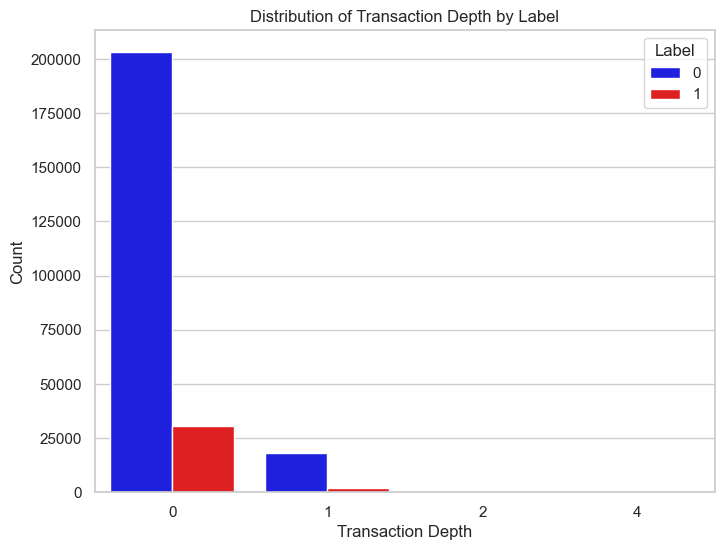

trans_depth
0    203114
1     18226
2       571
Name: count, dtype: int64

trans_depth
0    30376
1     1712
2        5
4        1
Name: count, dtype: int64

In [168]:
# Compare distribution of transaction depth across traffic types
plt.figure(figsize=(8, 6))
sns.countplot(
    data=df_eda,
    x="trans_depth",
    hue="Label",
    palette={0: "blue", 1: "red"}
)
plt.title("Distribution of Transaction Depth by Label")
plt.xlabel("Transaction Depth")
plt.ylabel("Count")
plt.show()

display(
    normal_subset["trans_depth"]
    .value_counts()
    .sort_index()
)

display(
    attack_subset["trans_depth"]
    .value_counts()
    .sort_index()
)

**Observations:**
- Transaction depth doesn't show meaningful separation by label in this dataset.
- Semantically, attacks might be expected to have shallower depths (single-shot) while normal flows could span multiple requests.
- In practice here, most flows have similar transaction counts so this feature is unlikely to be informative.

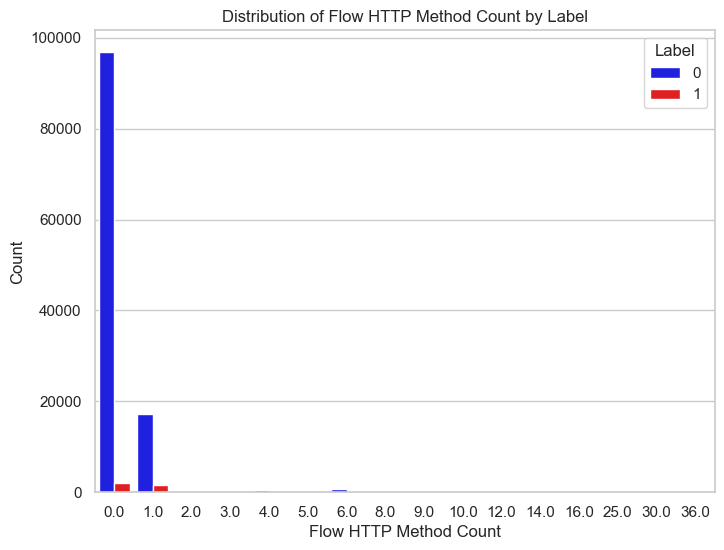

ct_flw_http_mthd
0.0     96798
1.0     17159
6.0       798
4.0       582
3.0        87
2.0        49
5.0        47
14.0       25
9.0        18
12.0       12
36.0        8
8.0         7
10.0        5
Name: count, dtype: int64

ct_flw_http_mthd
0.0     2090
1.0     1629
4.0       57
30.0       9
9.0        9
2.0        5
16.0       4
6.0        3
25.0       2
Name: count, dtype: int64

In [169]:
# Compare distribution of flow HTTP method count across traffic types
plt.figure(figsize=(8, 6))
sns.countplot(
    data=df_eda,
    x="ct_flw_http_mthd",
    hue="Label",
    palette={0: "blue", 1: "red"}
)
plt.title("Distribution of Flow HTTP Method Count by Label")
plt.xlabel("Flow HTTP Method Count")
plt.ylabel("Count")
plt.show()

display(
    normal_subset["ct_flw_http_mthd"]
    .value_counts()
    .sort_values(ascending=False)
)

display(
    attack_subset["ct_flw_http_mthd"]
    .value_counts()
    .sort_values(ascending=False)
)

**Observations:**
- Significant number of NaN values for both groups, indicating that non-HTTP flows comprise a large proportion of the dataset.
- No meaningful separation between groups; counts drop off quickly, becoming too sparse and injecting too much noise.